# Modulation analogique

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import pi
plt.style.use('../signal.mplstyle')

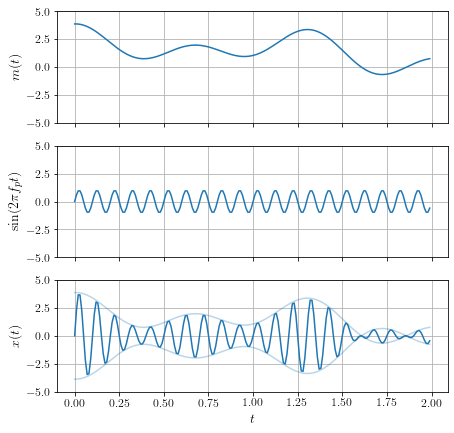

In [2]:
fe = 100
N = 200
n = np.arange(N)
t = n/fe
fp = 10
m = 1 + np.sin(2*pi*.2*t+pi/3) + np.sin(2*pi*.8*t+pi/2) + np.sin(2*pi*1.5*t+pi/2)
p = np.sin(2*pi*fp*t)
x = m * p

fig, axs = plt.subplots(3,1, figsize=(7,7), sharex=True)
for k in range(3):
    axs[k].set_ylim([-5, 5])
axs[0].plot(t, m)
axs[0].set_ylabel("$m(t)$")
axs[1].plot(t, p)
axs[1].set_ylabel("$\sin(2\pi f_p t)$")
axs[2].plot(t, m, color="C0", alpha=.3)
axs[2].plot(t, -m, color="C0", alpha=.3)
axs[2].plot(t, x, color="C0")
axs[2].set_ylabel("$x(t)$")
axs[2].set_xlabel("$t$")
plt.savefig("modulation-analogique-1.svg", bbox_inches="tight")
plt.show()

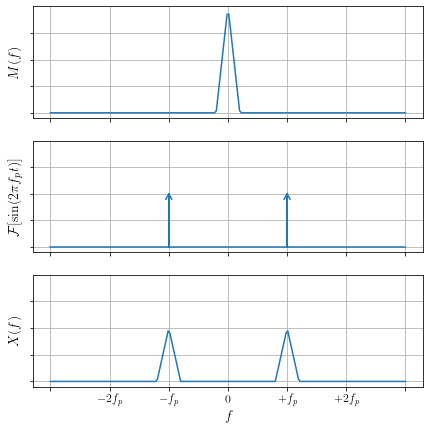

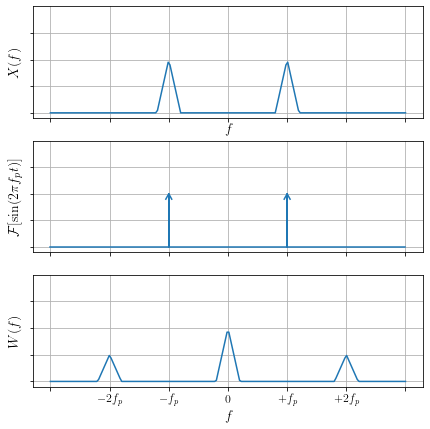

In [4]:
fmax = 3*fp

# Signaux
def tri(f, fo):
    return np.where(np.abs(f-fo)<2, 2-np.abs(f-fo), 0)

def dirac(f, fo):
    dx, dy = .5, .1
    x = np.array([fo-dx, fo, fo, fo, fo+dx])
    y = np.array([1-dy,   1,  0,  1,  1-dy])
    return x, y

def make_axis(axs):
    for k in range(3):
        axs[k].set_xticks(np.linspace(-fmax, fmax, 7))
        axs[k].set_yticks(np.arange(0, 2, .5))
        axs[k].set_xticklabels(["", "$-2 f_p$", "$-f_p$", "0", "$+f_p$", "$+2 f_p$", ""])
        axs[k].set_yticklabels([])
        axs[k].set_ylim([-.1, 2])
    
f = np.linspace(-fmax, fmax, N)
M = tri(f, 0)


# Modulation

fig, axs = plt.subplots(3,1, figsize=(7,7), sharex=True)

axs[0].plot(f, M)
axs[0].set_ylabel("$M(f)$")

axs[1].plot([-fmax, fmax], [0, 0], "C0")
x, y = dirac(f, fp)
axs[1].plot(x, y, "C0")
x, y = dirac(f, -fp)
axs[1].plot(x, y, "C0")
axs[1].set_ylabel("$\mathcal{F}[\sin(2\pi f_p t)]$")

X = tri(f, -fp)/2 + tri(f, fp)/2
axs[2].plot(f, X)
axs[2].set_ylabel("$X(f)$")
axs[2].set_xlabel("$f$")

make_axis(axs)
plt.savefig("modulation-analogique-2.svg", bbox_inches="tight")
plt.show()


# Démodulation

fig, axs = plt.subplots(3,1, figsize=(7,7), sharex=True)

X = tri(f, -fp)/2 + tri(f, fp)/2
axs[0].plot(f, X)
axs[0].set_ylabel("$X(f)$")
axs[0].set_xlabel("$f$")

axs[1].plot([-fmax, fmax], [0, 0], "C0")
x, y = dirac(f, fp)
axs[1].plot(x, y, "C0")
x, y = dirac(f, -fp)
axs[1].plot(x, y, "C0")
axs[1].set_ylabel("$\mathcal{F}[\sin(2\pi f_p t)]$")

W = tri(f, -2*fp)/4 + 2*tri(f, 0)/4 + tri(f, 2*fp)/4
axs[2].plot(f, W)
axs[2].set_ylabel("$W(f)$")
axs[2].set_xlabel("$f$")

make_axis(axs)
plt.savefig("modulation-analogique-3.svg", bbox_inches="tight")
plt.show()